<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Ses2_visualizar_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Portada CDA](https://drive.google.com/uc?export=view&id=1U9hCpCqZyqnCwjMACrD_YgUdJSNPrEFZ)

# Sesión 2: Visualización de Datos Ambientales
## Matplotlib y Folium — Calidad del Aire en Lima (SENAMHI)

**Maestría en Ciencia de Datos Ambientales | UTEC**

---

Un buen gráfico comunica en segundos lo que una tabla tarda minutos en transmitir.
En esta sesión aprenderás a construir visualizaciones claras y precisas con datos
reales de calidad del aire de Lima Metropolitana.

### Dataset de la sesión

| Dataset | Fuente | Variables |
|---|---|---|
| Calidad del aire — Lima | SENAMHI | PM10, PM2.5, NO2 · 7 estaciones · 2015–2024 |

### Objetivos de aprendizaje

1. Entender la anatomía de una figura matplotlib (Figure, Axes, elementos)
2. Crear barras simples, agrupadas y horizontales
3. Interpretar histogramas y boxplots de variables ambientales
4. Crear gráficos de dispersión con color por categoría
5. Combinar múltiples gráficos en un panel con `subplots`
6. Construir mapas interactivos con `folium`


---
## Parte 1: Importar librerías y cargar datos

In [ ]:
!pip install folium --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import folium

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']   = 10

print("Listo")

Listo


In [ ]:
# Dataset: Monitoreo de contaminantes del aire — Lima Metropolitana (SENAMHI)
# Fuente: datos abiertos SENAMHI | Periodo: 2015–2024 | ~578k registros horarios
URL_AIRE = 'https://drive.google.com/uc?export=download&confirm=t&id=1Q5H9G0ETWzH1mU8_Dxjdl9b2fvOfgoGc'

aire_raw = pd.read_csv(URL_AIRE, encoding='latin1')

# Limpieza rápida de fecha y hora
aire_raw['fecha'] = pd.to_datetime(aire_raw['FECHA'].astype(str), format='%Y%m%d')
aire_raw['anio']  = aire_raw['fecha'].dt.year
aire_raw['hora_num'] = (aire_raw['HORA'] // 10000).astype(int)

# Resumen por estación (promedio del periodo completo)
aire = (
    aire_raw.groupby('ESTACION')
    .agg(
        lat      = ('LATITUD',  'first'),
        lon      = ('LONGITUD', 'first'),
        altitud  = ('ALTITUD',  'first'),
        distrito = ('DISTRITO', 'first'),
        pm10_med = ('PM10',  'mean'),
        pm10_max = ('PM10',  'max'),
        pm10_p90 = ('PM10',  lambda x: x.quantile(.9)),
        pm25_med = ('PM2_5', 'mean'),
        no2_med  = ('NO2',   'mean'),
        n_obs    = ('PM10',  'count'),
    )
    .round(2)
    .reset_index()
)

ECA_PM10_24h  = 100   # µg/m³ — DS 003-2017-MINAM
ECA_PM10_anual = 50

print(f"Dataset: {len(aire_raw):,} mediciones  |  {len(aire)} estaciones")
aire[['ESTACION','distrito','pm10_med','pm25_med','no2_med']]

Dataset: 577,794 mediciones  |  7 estaciones


,ESTACION,distrito,pm10_med,pm25_med,no2_med
0,CAMPO_DE_MARTE,JESUS_MARIA,30.72,16.91,17.86
1,CARABAYLLO,CARABAYLLO,71.79,27.85,22.57
2,SANTA_ANITA,SANTA_ANITA,62.94,30.04,25.37
3,SAN_BORJA,SAN_BORJA,58.77,18.67,20.95
4,SAN_JUAN_DE_LURIGANCHO,SAN_JUAN_DE_LURIGANCHO,74.87,31.38,31.38
5,SAN_MARTIN_DE_PORRES,SAN_MARTIN_DE_PORRES,41.51,18.68,23.08
6,VILLA_MARIA_DEL_TRIUNFO,VILLA_MARIA_DEL_TRIUNFO,97.43,26.26,17.75


---
## Parte 2: Anatomía de un gráfico matplotlib

```
fig, ax = plt.subplots(figsize=(ancho, alto))
```

| Elemento | Qué es | Cómo se configura |
|---|---|---|
| **Figure** | El lienzo completo | `fig = plt.figure()` |
| **Axes** | El área del gráfico | `ax = fig.add_subplot()` |
| **Title** | Título del gráfico | `ax.set_title('...')` |
| **xlabel/ylabel** | Etiquetas de ejes | `ax.set_xlabel('...')` |
| **Legend** | Leyenda | `ax.legend()` |
| **axhline/axvline** | Línea de referencia | `ax.axhline(valor)` |


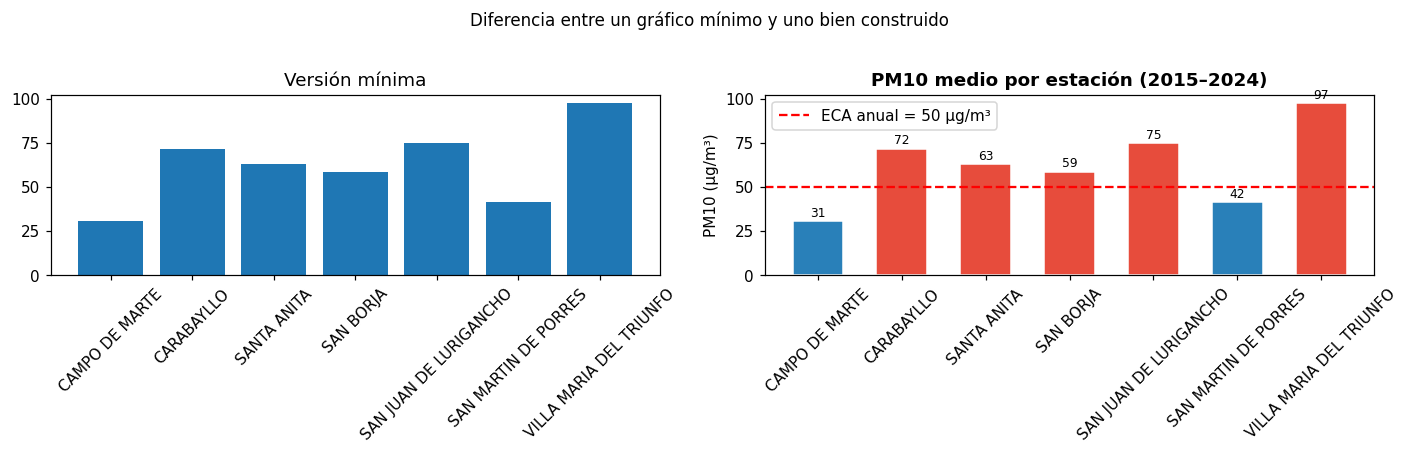

In [ ]:
# Gráfico mínimo vs gráfico bien construido
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

estaciones = aire['ESTACION'].str.replace('_', ' ', regex=False)
valores    = aire['pm10_med']

# Izquierda: mínimo
ax1.bar(estaciones, valores)
ax1.set_title('Versión mínima')
ax1.tick_params(axis='x', rotation=45)

# Derecha: completo
ECA_PM10 = 50   # µg/m³ — ECA anual DS 003-2017-MINAM
colores  = ['#E74C3C' if v > ECA_PM10 else '#2980B9' for v in valores]

ax2.bar(estaciones, valores, color=colores, edgecolor='white', width=0.6)
ax2.axhline(ECA_PM10, color='red', linestyle='--', linewidth=1.5,
            label=f'ECA anual = {ECA_PM10} µg/m³')
ax2.set_title('PM10 medio por estación (2015–2024)', fontweight='bold')
ax2.set_ylabel('PM10 (µg/m³)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

for bar, v in zip(ax2.patches, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{v:.0f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Diferencia entre un gráfico mínimo y uno bien construido',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## Parte 3: Gráficos de Barras

**Ideales para:** comparar cantidades entre categorías discretas.

> Regla práctica: usa **barras horizontales** cuando las etiquetas son largas;
> **barras verticales** cuando son cortas o son fechas.


### 3.2 Barras agrupadas — PM10, PM2.5 y NO₂ por estación

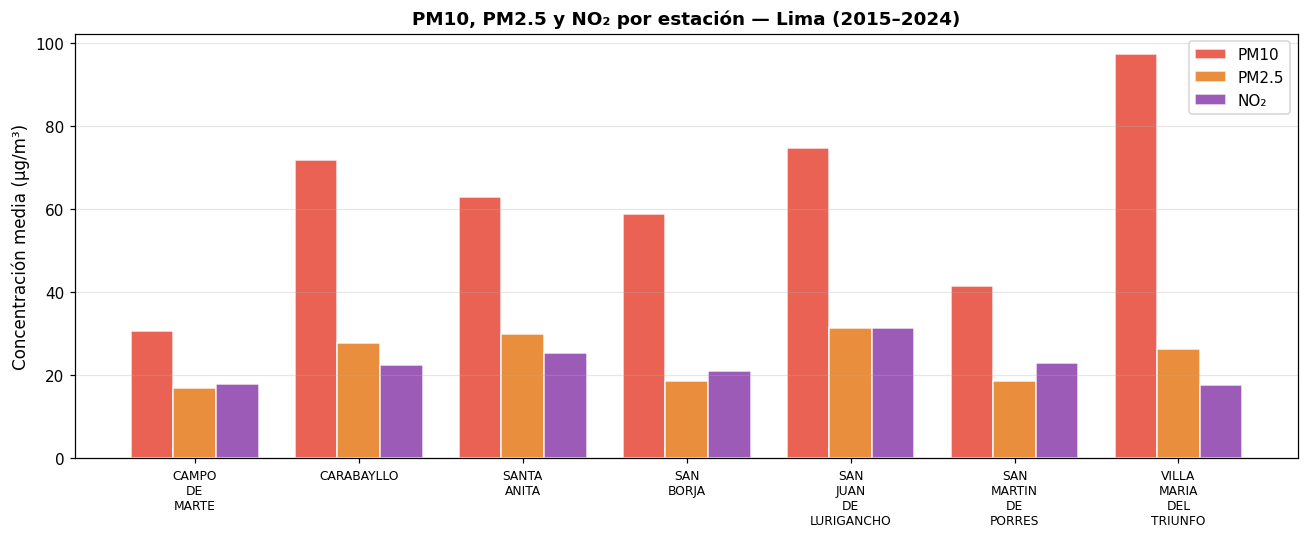

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

contaminantes = ['pm10_med', 'pm25_med', 'no2_med']
etiquetas_c   = ['PM10', 'PM2.5', 'NO₂']
colores_c     = ['#E74C3C', '#E67E22', '#8E44AD']

n   = len(aire)
x   = np.arange(n)
ancho = 0.26

for i, (col, label, color) in enumerate(zip(contaminantes, etiquetas_c, colores_c)):
    offset = (i - 1) * ancho
    bars   = ax.bar(x + offset, aire[col], ancho,
                    label=label, color=color, edgecolor='white', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(aire['ESTACION'].str.replace('_', '\n', regex=False), fontsize=8)
ax.set_ylabel('Concentración media (µg/m³)', fontsize=11)
ax.set_title('PM10, PM2.5 y NO₂ por estación — Lima (2015–2024)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> **Ejercicio rápido 1** — Barras
>
> Crea un gráfico de barras horizontales con la **concentración máxima de PM10**
> por estación (`aire['pm10_max']`). Agrega una línea vertical en el ECA de 24h (100 µg/m³).
> ¿Qué estación registró el pico más alto?


In [ ]:
# Tu código aquí


---
## Parte 4: Distribuciones — Histograma y Boxplot

**Histograma:** muestra cuántas observaciones caen en cada rango de valores.
**Boxplot:** muestra mediana, cuartiles y valores extremos de forma compacta.


### 4.1 Histograma — distribución de PM10 en Lima

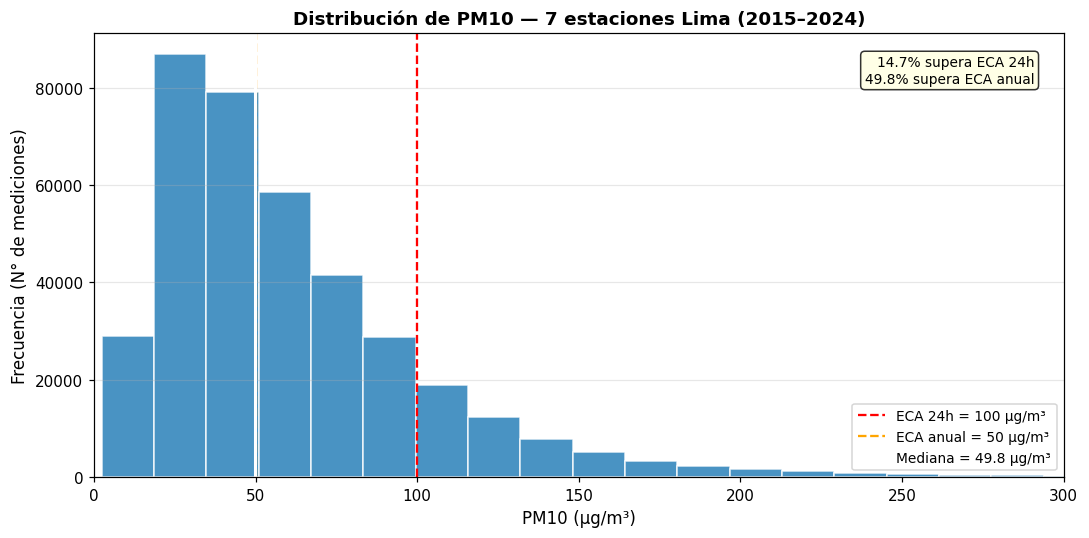

In [ ]:
pm10_vals = aire_raw['PM10'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(pm10_vals, bins=60, color='#2980B9', edgecolor='white',
        alpha=0.85, density=False)

ECA_24h  = 100
ECA_anual = 50
ax.axvline(ECA_24h,  color='red',    linestyle='--', linewidth=1.5,
           label=f'ECA 24h = {ECA_24h} µg/m³')
ax.axvline(ECA_anual, color='orange', linestyle='--', linewidth=1.5,
           label=f'ECA anual = {ECA_anual} µg/m³')
ax.axvline(pm10_vals.median(), color='white', linestyle='-', linewidth=2,
           label=f'Mediana = {pm10_vals.median():.1f} µg/m³')

ax.set_xlabel('PM10 (µg/m³)', fontsize=11)
ax.set_ylabel('Frecuencia (N° de mediciones)', fontsize=11)
ax.set_title('Distribución de PM10 — 7 estaciones Lima (2015–2024)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 300)   # recortar la cola larga para mejor visualización
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Anotar % que supera ECA
pct_24h   = (pm10_vals > ECA_24h).mean() * 100
pct_anual = (pm10_vals > ECA_anual).mean() * 100
ax.text(0.97, 0.95,
        f'{pct_24h:.1f}% supera ECA 24h\n{pct_anual:.1f}% supera ECA anual',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

### 4.2 Boxplot — variación de PM10 por estación

/tmp/ipykernel_5353/1742789523.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box, labels=etiq_box, patch_artist=True,


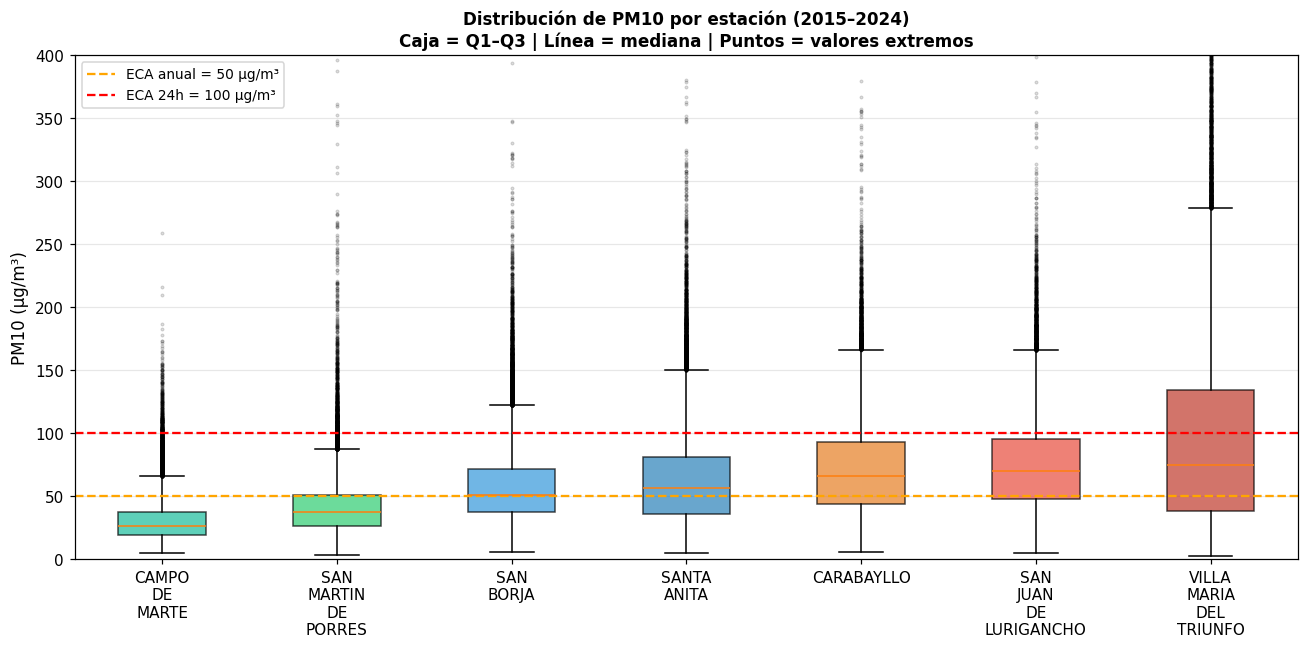

In [ ]:
# Preparar datos: lista de arrays, uno por estación
estaciones_ord = (aire.sort_values('pm10_med')['ESTACION'].tolist())
datos_box = [aire_raw[aire_raw['ESTACION'] == est]['PM10'].dropna().values
             for est in estaciones_ord]
etiq_box  = [e.replace('_', '\n') for e in estaciones_ord]

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(datos_box, labels=etiq_box, patch_artist=True,
                showfliers=True, flierprops=dict(marker='.', alpha=0.2, markersize=3))

colores_box = ['#1ABC9C','#2ECC71','#3498DB','#2980B9','#E67E22','#E74C3C','#C0392B']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(ECA_anual, color='orange', linestyle='--', linewidth=1.5,
           label=f'ECA anual = {ECA_anual} µg/m³')
ax.axhline(ECA_24h,   color='red',    linestyle='--', linewidth=1.5,
           label=f'ECA 24h = {ECA_24h} µg/m³')

ax.set_ylabel('PM10 (µg/m³)', fontsize=11)
ax.set_title('Distribución de PM10 por estación (2015–2024)\n'
             'Caja = Q1–Q3 | Línea = mediana | Puntos = valores extremos',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 400)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> **Ejercicio rápido 2** — Histograma
>
> Crea un histograma de **PM2.5** (columna `PM2_5`) del dataset `aire_raw`.
> Agrega líneas verticales para el ECA anual de PM2.5 (25 µg/m³) y el de 24h (50 µg/m³).
> ¿Qué porcentaje de mediciones supera el ECA de 24h?


In [ ]:
# Tu código aquí


---
## Parte 5: Gráficos de Dispersión

**Ideales para:** explorar relaciones entre dos variables numéricas continuas.


### 5.1 Scatter PM10 vs PM2.5 — color por estación

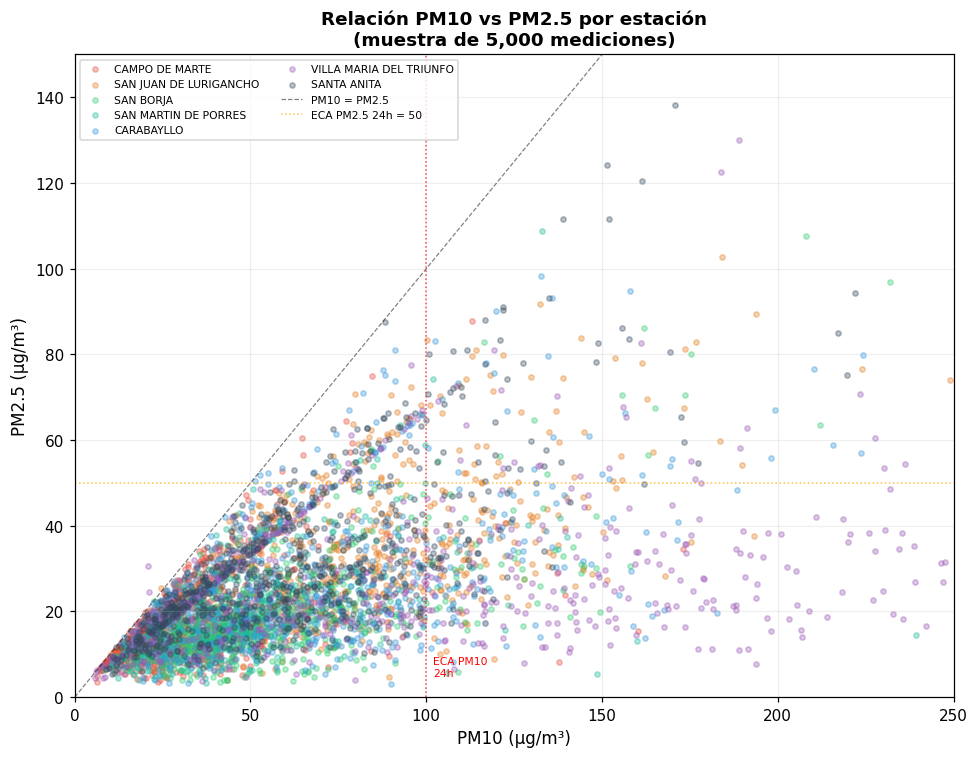

In [ ]:
# Muestra aleatoria para no graficar 500k puntos
muestra = aire_raw[['PM10','PM2_5','ESTACION']].dropna().sample(5000, random_state=42)

estaciones_unicas = muestra['ESTACION'].unique()
paleta = ['#E74C3C','#E67E22','#2ECC71','#1ABC9C','#3498DB','#9B59B6','#34495E']
color_map = dict(zip(estaciones_unicas, paleta))

fig, ax = plt.subplots(figsize=(9, 7))

for est in estaciones_unicas:
    sub = muestra[muestra['ESTACION'] == est]
    ax.scatter(sub['PM10'], sub['PM2_5'],
               color=color_map[est], alpha=0.35, s=12,
               label=est.replace('_', ' '))

# Línea 1:1 de referencia
lim = 250
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label='PM10 = PM2.5')

# ECA
ax.axvline(ECA_24h,  color='red',    linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(50,       color='orange', linestyle=':', linewidth=1, alpha=0.7,
           label='ECA PM2.5 24h = 50')
ax.text(ECA_24h + 2, 5, 'ECA PM10\n24h', color='red', fontsize=7)

ax.set_xlabel('PM10 (µg/m³)', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.set_title('Relación PM10 vs PM2.5 por estación\n(muestra de 5,000 mediciones)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, lim); ax.set_ylim(0, 150)
ax.legend(fontsize=7, ncol=2, loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 5.2 Scatter con color continuo — concentración vs altitud de estación

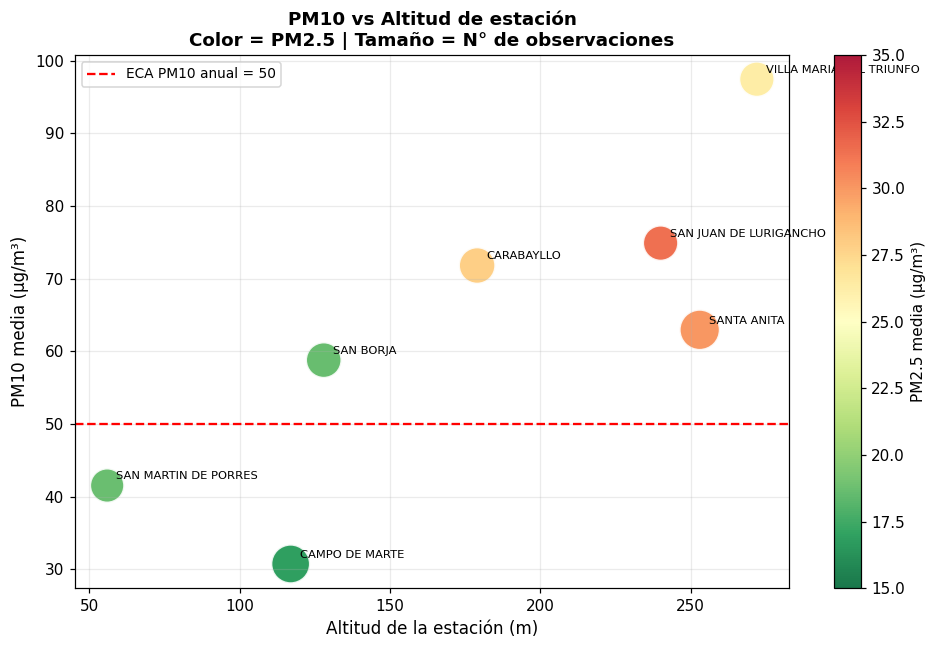

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    aire['altitud'], aire['pm10_med'],
    c=aire['pm25_med'],
    s=aire['n_obs'] / aire['n_obs'].max() * 600 + 100,   # tamaño ∝ N mediciones
    cmap='RdYlGn_r', vmin=15, vmax=35,
    edgecolors='white', linewidth=1.5, alpha=0.9
)

# Etiquetas de cada estación
for _, row in aire.iterrows():
    ax.annotate(row['ESTACION'].replace('_',' '),
                (row['altitud'], row['pm10_med']),
                xytext=(6, 4), textcoords='offset points', fontsize=7.5)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('PM2.5 media (µg/m³)', fontsize=10)

ax.axhline(ECA_anual, color='red', linestyle='--', linewidth=1.5,
           label=f'ECA PM10 anual = {ECA_anual}')
ax.set_xlabel('Altitud de la estación (m)', fontsize=11)
ax.set_ylabel('PM10 media (µg/m³)', fontsize=11)
ax.set_title('PM10 vs Altitud de estación\nColor = PM2.5 | Tamaño = N° de observaciones',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

---
## Parte 6: Panel de gráficos con `subplots`

`plt.subplots(filas, columnas)` crea una cuadrícula de gráficos.
Útil para presentar múltiples ángulos de los mismos datos en una sola figura.


/tmp/ipykernel_5353/4114672329.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_b, vert=False, patch_artist=True,


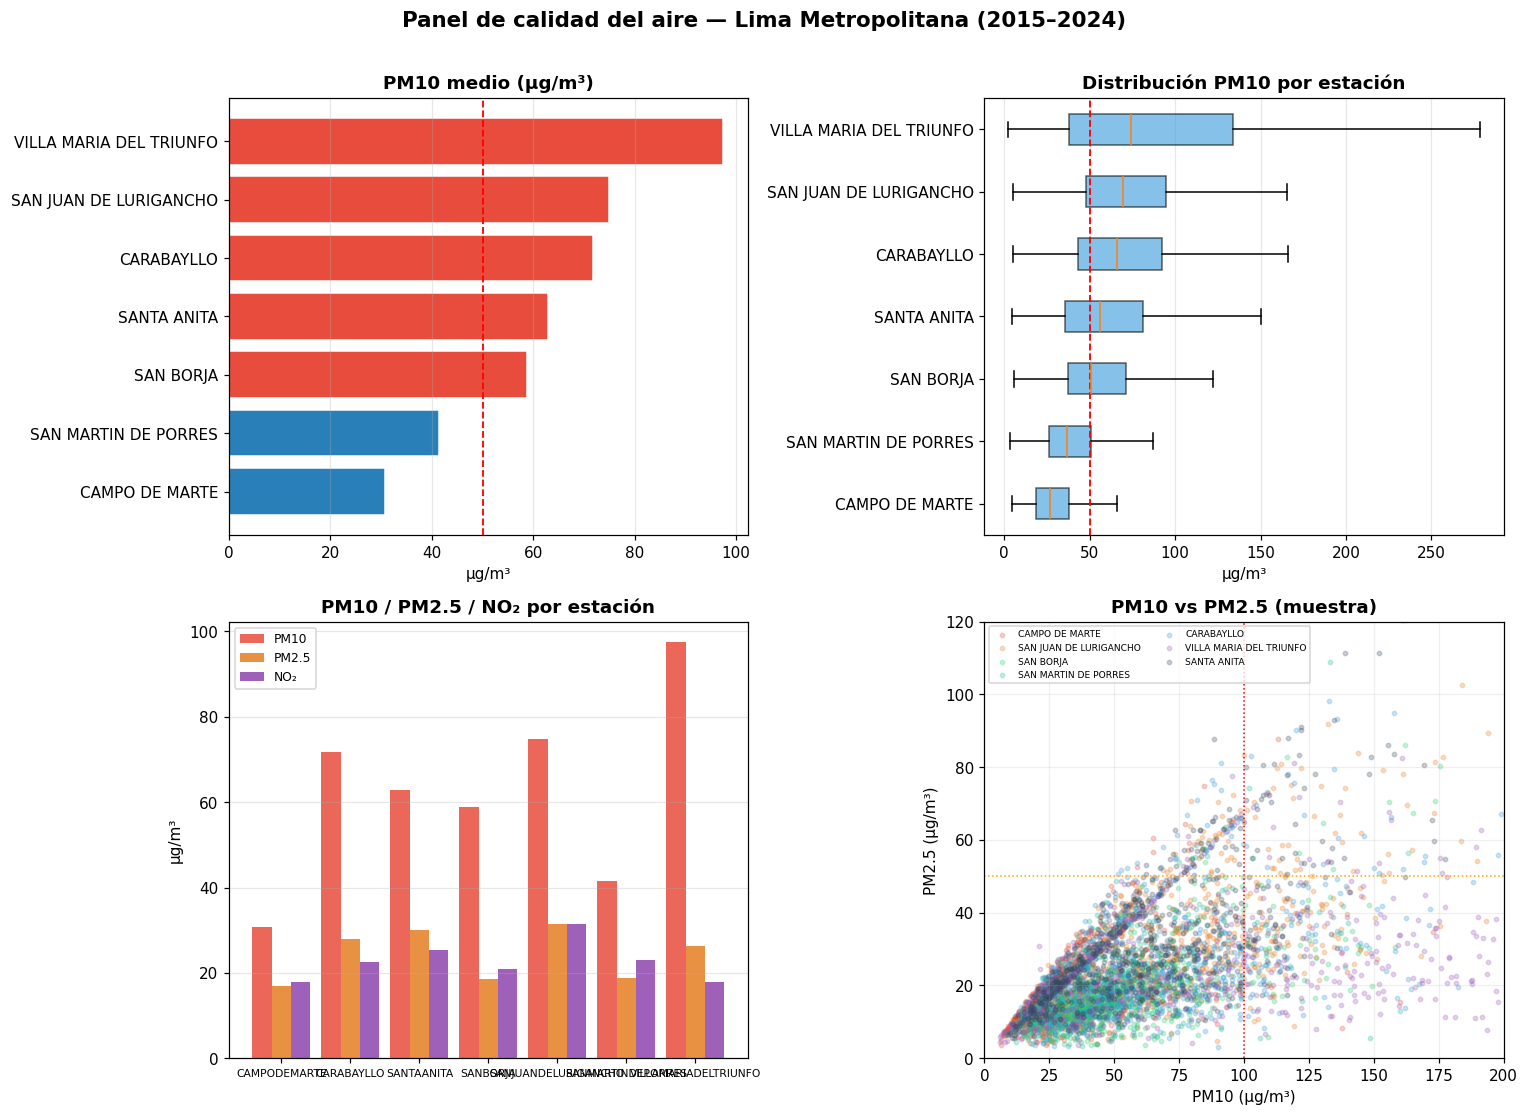

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Panel de calidad del aire — Lima Metropolitana (2015–2024)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel (0,0): PM10 medio por estación ──────────────────────────────────────
ax = axes[0, 0]
est_sorted = aire.sort_values('pm10_med', ascending=True)
colores_p  = ['#E74C3C' if v > ECA_anual else '#2980B9' for v in est_sorted['pm10_med']]
ax.barh(est_sorted['ESTACION'].str.replace('_', ' ', regex=False),
        est_sorted['pm10_med'], color=colores_p, edgecolor='white')
ax.axvline(ECA_anual, color='red', linestyle='--', linewidth=1.2)
ax.set_title('PM10 medio (µg/m³)', fontweight='bold')
ax.set_xlabel('µg/m³')
ax.grid(axis='x', alpha=0.3)

# ── Panel (0,1): Boxplot PM10 por estación ────────────────────────────────────
ax = axes[0, 1]
datos_b = [aire_raw[aire_raw['ESTACION']==e]['PM10'].dropna().values
           for e in est_sorted['ESTACION']]
bp = ax.boxplot(datos_b, vert=False, patch_artist=True,
                showfliers=False,
                labels=est_sorted['ESTACION'].str.replace('_', ' ', regex=False))
for patch in bp['boxes']:
    patch.set_facecolor('#3498DB'); patch.set_alpha(0.6)
ax.axvline(ECA_anual, color='red', linestyle='--', linewidth=1.2)
ax.set_title('Distribución PM10 por estación', fontweight='bold')
ax.set_xlabel('µg/m³')
ax.grid(axis='x', alpha=0.3)

# ── Panel (1,0): Comparación PM10 / PM2.5 / NO2 ──────────────────────────────
ax = axes[1, 0]
x_  = np.arange(len(aire))
w_  = 0.28
for i,(col,lab,col_c) in enumerate(zip(['pm10_med','pm25_med','no2_med'],
                                        ['PM10','PM2.5','NO₂'],
                                        ['#E74C3C','#E67E22','#8E44AD'])):
    ax.bar(x_ + (i-1)*w_, aire[col], w_, label=lab, color=col_c, alpha=0.85)
ax.set_xticks(x_)
ax.set_xticklabels(aire['ESTACION'].str.replace('_','',regex=False), fontsize=7)
ax.set_title('PM10 / PM2.5 / NO₂ por estación', fontweight='bold')
ax.set_ylabel('µg/m³')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel (1,1): Dispersión PM10 vs PM2.5 por estación ───────────────────────
ax = axes[1, 1]
for est, color in zip(estaciones_unicas, paleta):
    sub = muestra[muestra['ESTACION']==est]
    ax.scatter(sub['PM10'], sub['PM2_5'], color=color, alpha=0.25, s=8,
               label=est.replace('_',' '))
ax.axvline(ECA_24h, color='red',    linestyle=':', linewidth=1)
ax.axhline(50,      color='orange', linestyle=':', linewidth=1)
ax.set_xlabel('PM10 (µg/m³)'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlim(0,200); ax.set_ylim(0,120)
ax.set_title('PM10 vs PM2.5 (muestra)', fontweight='bold')
ax.legend(fontsize=6, ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# Tu código aquí


---
## Parte 7: Mapas interactivos con Folium

`folium` permite crear mapas web interactivos directamente en el notebook.
Puedes hacer zoom, click en marcadores y personalizar colores.

```python
mapa = folium.Map(location=[lat, lon], zoom_start=11)
folium.CircleMarker(location=[lat, lon], ...).add_to(mapa)
mapa   # mostrar en el notebook
```


### 7.1 Mapa de estaciones de calidad del aire — Lima

In [ ]:
def color_pm10(val):
    if val > ECA_anual:   return '#E74C3C'   # rojo: supera ECA anual
    elif val > ECA_anual * 0.75: return '#E67E22'  # naranja: 75-100% del ECA
    else:                  return '#2ECC71'   # verde: dentro del ECA

mapa_aire = folium.Map(location=[-12.05, -77.02], zoom_start=11,
                       tiles='CartoDB positron')

for _, row in aire.iterrows():
    color = color_pm10(row['pm10_med'])
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=14,
        color='white', weight=2,
        fill=True, fill_color=color, fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>{row['ESTACION'].replace('_',' ')}</b><br>"
            f"Distrito: {row['distrito'].replace('_',' ')}<br>"
            f"Altitud: {row['altitud']:.0f} m<br><hr>"
            f"PM10 media: <b>{row['pm10_med']:.1f} µg/m³</b><br>"
            f"PM10 P90:   {row['pm10_p90']:.1f} µg/m³<br>"
            f"PM10 máx:   {row['pm10_max']:.1f} µg/m³<br>"
            f"PM2.5 media:{row['pm25_med']:.1f} µg/m³<br>"
            f"NO2 media:  {row['no2_med']:.1f} µg/m³",
            max_width=220
        ),
        tooltip=f"{row['ESTACION'].replace('_',' ')} | PM10: {row['pm10_med']:.1f} µg/m³"
    ).add_to(mapa_aire)

# Leyenda
leyenda_aire = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
    'background:white;padding:10px;border-radius:6px;border:1px solid #ccc;font-size:12px;">'
    '<b>PM10 media anual</b><br>'
    '<span style="color:#2ECC71;font-size:16px;">&#9679;</span> &lt; 37.5 µg/m³ (bueno)<br>'
    '<span style="color:#E67E22;font-size:16px;">&#9679;</span> 37.5–50 µg/m³ (moderado)<br>'
    '<span style="color:#E74C3C;font-size:16px;">&#9679;</span> &gt; 50 µg/m³ (supera ECA anual)'
    '</div>'
)
mapa_aire.get_root().html.add_child(folium.Element(leyenda_aire))

mapa_aire

### 7.3 Mapa con marcadores personalizados — ícono por nivel de contaminación

In [ ]:
# Excedencias de PM10 por estación: círculos con radio proporcional al exceso
mapa_exc = folium.Map(location=[-12.05, -77.02], zoom_start=11,
                      tiles='OpenStreetMap')

for _, row in aire.iterrows():
    exceso = max(0, row['pm10_med'] - ECA_anual)
    color  = color_pm10(row['pm10_med'])

    # Círculo grande de "impacto"
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=exceso * 150 + 500,    # radio en metros, proporcional al exceso
        color=color, fill=True, fill_opacity=0.15, weight=2
    ).add_to(mapa_exc)

    # Marcador central
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"{row['ESTACION'].replace('_',' ')}<br>PM10: {row['pm10_med']:.1f} µg/m³",
        icon=folium.Icon(color='red' if row['pm10_med'] > ECA_anual else 'blue',
                         icon='cloud', prefix='fa')
    ).add_to(mapa_exc)

mapa_exc

---
## Resumen

| Tipo de gráfico | Función | Ideal para |
|---|---|---|
| Barras verticales | `ax.bar()` | Comparar categorías cortas |
| Barras horizontales | `ax.barh()` | Categorías con nombres largos |
| Barras agrupadas | `ax.bar(x+offset, ...)` | Comparar múltiples series |
| Histograma | `ax.hist()` | Distribución de una variable |
| Boxplot | `ax.boxplot()` | Comparar distribuciones entre grupos |
| Dispersión | `ax.scatter()` | Relación entre dos variables numéricas |
| Panel | `plt.subplots(f, c)` | Múltiples gráficos en una figura |
| Mapa base | `folium.Map()` | Visualización espacial interactiva |
| Marcador circular | `folium.CircleMarker()` | Puntos con color/tamaño personalizado |
| Área de impacto | `folium.Circle()` | Radio proporcional a un valor |

### Elementos esenciales en todo gráfico
```python
ax.set_title('Título descriptivo', fontweight='bold')
ax.set_xlabel('Variable x (unidades)')
ax.set_ylabel('Variable y (unidades)')
ax.axhline(valor_referencia, linestyle='--', label='ECA ...')
ax.legend()
plt.tight_layout()
```


---
# TAREA: Panel de visualización — Calidad del Aire por Estación

## Enunciado

Con el dataset de calidad del aire (`aire_raw` y `aire`), crea un panel de
visualizaciones que compare las 7 estaciones de Lima. Enfócate en comunicar
**cuáles estaciones tienen peor calidad del aire y en qué contaminante**.

---

### Panel requerido — `plt.subplots(2, 2, figsize=(14, 10))`

| Posición | Gráfico | Datos |
|---|---|---|
| (0,0) | Barras horizontales | PM10 medio por estación, con línea ECA anual (50 µg/m³) |
| (0,1) | Barras agrupadas | PM10 / PM2.5 / NO2 por estación |
| (1,0) | Histograma | Distribución de PM2.5 con líneas ECA (25 y 50 µg/m³) |
| (1,1) | Boxplot | PM10 por estación, sin valores extremos (`showfliers=False`) |

### Mapa folium

Crea un mapa de las 7 estaciones donde:
- El color del marcador refleje el nivel de PM2.5 (verde/naranja/rojo)
- El popup muestre PM10, PM2.5 y NO2 de esa estación
- Agrega una leyenda con los umbrales usados

### ECA de referencia (DS 003-2017-MINAM)

```python
ECA = {
    'PM10':  {'24h': 100, 'anual': 50},
    'PM2_5': {'24h': 50,  'anual': 25},
    'NO2':   {'24h': 100},
}
```

---

### Entregable

`Tarea2_[Apellido]_CalidadAire_Viz.ipynb` con:
- Panel de 4 gráficos con títulos, etiquetas y líneas de referencia ECA
- Mapa folium con leyenda
- Celda de conclusiones: ¿Qué estación tiene la peor calidad del aire?
  ¿El PM2.5 supera con más frecuencia su ECA que el PM10?


In [ ]:
# Panel 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tu código aquí


In [ ]:
# Mapa folium
# Tu código aquí


### Conclusiones

*Escribe aquí tus hallazgos (3–5 oraciones)*

...

---
## Soluciones — Ejercicios rápidos

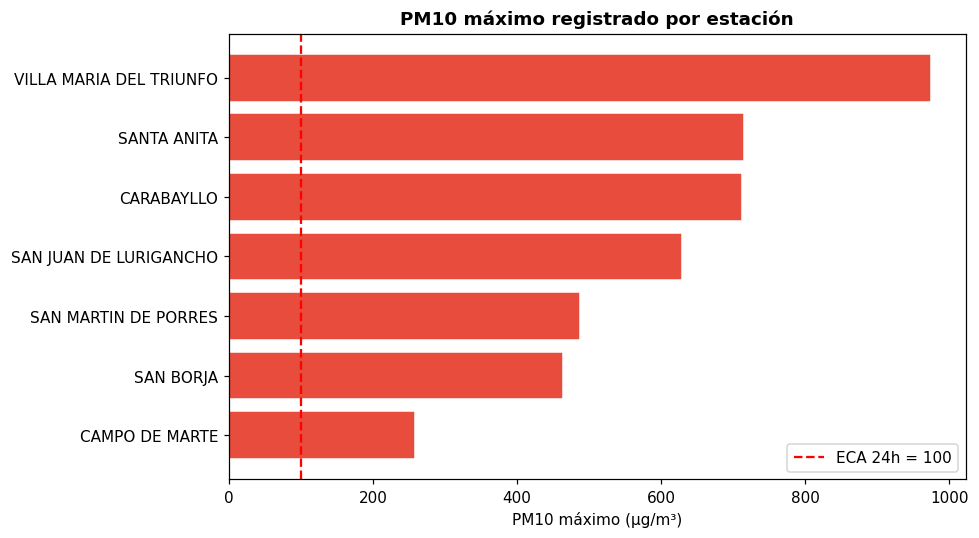

In [ ]:
# Solución Ejercicio 1 — Barras horizontales PM10 máximo
fig, ax = plt.subplots(figsize=(9, 5))
max_sorted = aire.sort_values('pm10_max')
ax.barh(max_sorted['ESTACION'].str.replace('_',' ',regex=False),
        max_sorted['pm10_max'], color='#E74C3C', edgecolor='white')
ax.axvline(100, color='red', linestyle='--', linewidth=1.5, label='ECA 24h = 100')
ax.set_xlabel('PM10 máximo (µg/m³)'); ax.legend()
ax.set_title('PM10 máximo registrado por estación', fontweight='bold')
plt.tight_layout(); plt.show()

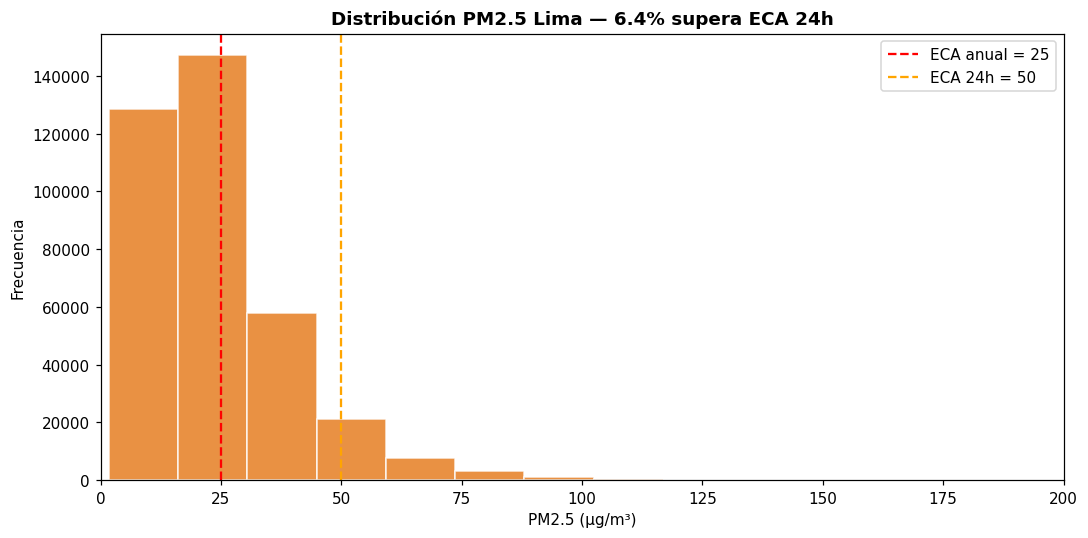

In [ ]:
# Solución Ejercicio 2 — Histograma PM2.5
pm25 = aire_raw['PM2_5'].dropna()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pm25, bins=50, color='#E67E22', edgecolor='white', alpha=0.85)
ax.axvline(25, color='red',    linestyle='--', linewidth=1.5, label='ECA anual = 25')
ax.axvline(50, color='orange', linestyle='--', linewidth=1.5, label='ECA 24h = 50')
pct = (pm25 > 50).mean() * 100
ax.set_xlabel('PM2.5 (µg/m³)'); ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución PM2.5 Lima — {pct:.1f}% supera ECA 24h', fontweight='bold')
ax.set_xlim(0, 200); ax.legend(); plt.tight_layout(); plt.show()